In [97]:
from neurostatsmodels.integration import *

seed = None
n_trials = 100
total_time_ms = 1000
n_epochs = 3
nonlinear = True
per_trial_normalization = 'unit_gaussian' #'divide_by_max'
total_rate_hz = 10

# typical spine
typical_options = IntegratorOptions(
    total_time_ms=total_time_ms,
    n_epochs=n_epochs,
    random_seed=seed,
    n_trials=n_trials,
    n_synapses=1,
    morphology_amplitude_range=(10.0, 10.0),
    morphology_tau_range=(1.0, 1.0),
    nonlinear=nonlinear,
    total_rate_hz=total_rate_hz,
)
typical_sim = Integrator(typical_options)

# complex spine
complex_options = IntegratorOptions(
    total_time_ms=total_time_ms,
    n_epochs=n_epochs,
    random_seed=seed,
    n_trials=n_trials,
    n_synapses=10,
    morphology_amplitude_range=(1.0, 10.0),
    morphology_tau_range=(1.0, 10.0),
    nonlinear=nonlinear,
    active_synapse_fraction='random',
    total_rate_hz=total_rate_hz,
)
complex_sim = Integrator(complex_options)

rng = np.random.default_rng(seed=seed)

print("Running typical spine...")
Y_typical = typical_sim.run_trials(per_trial_normalization=per_trial_normalization)

print("Running complex spine...")
Y_complex = complex_sim.run_trials(per_trial_normalization=per_trial_normalization)

pr_typical, sv_typical = typical_sim.compute_participation_ratio(Y_typical)
pr_complex, sv_complex = complex_sim.compute_participation_ratio(Y_complex)

print("\nParticipation ratio")
print("Typical spine:")
print(f"PR = {pr_typical:0.3}\tPR/n = {pr_typical/n_trials:0.3}")
print("Complex spine:")
print(f"PR = {pr_complex:0.3}\tPR/n = {pr_complex/n_trials:0.3}")

Running typical spine...


100%|██████████| 100/100 [00:00<00:00, 1221.17it/s]


Running complex spine...


100%|██████████| 100/100 [00:00<00:00, 144.31it/s]



Participation ratio
Typical spine:
PR = 77.6	PR/n = 0.776
Complex spine:
PR = 62.5	PR/n = 0.625


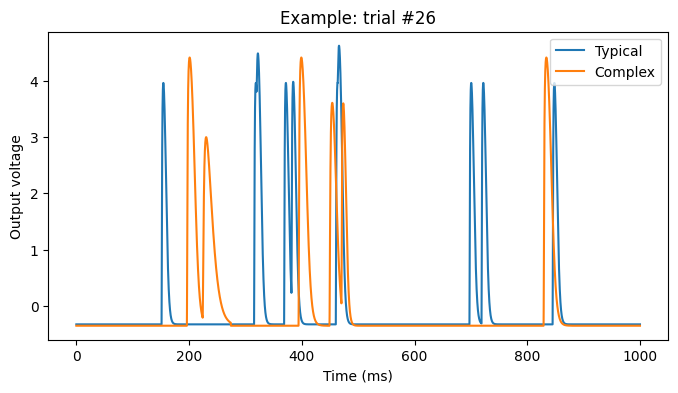

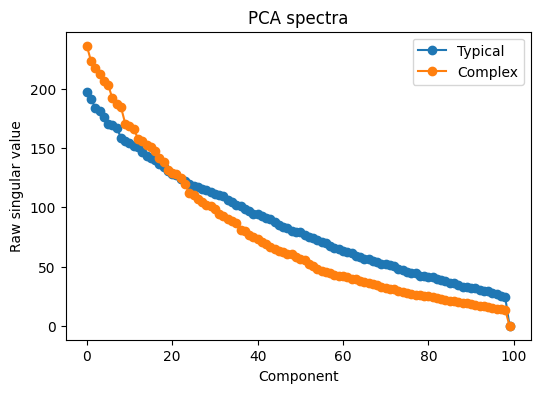

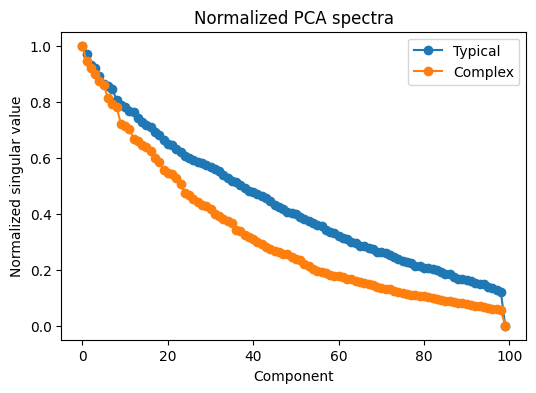

In [98]:
example_idx = rng.integers(low=0, high=n_trials)
plt.figure(figsize=(8, 4))
plt.plot(typical_sim.time, Y_typical[example_idx], label="Typical")
plt.plot(complex_sim.time, Y_complex[example_idx], label="Complex")
plt.xlabel("Time (ms)")
plt.ylabel("Output voltage")
plt.title(f"Example: trial #{example_idx}")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(sv_typical, "o-", label="Typical")
plt.plot(sv_complex, "o-", label="Complex")
plt.xlabel("Component")
plt.ylabel("Raw singular value")
plt.title("PCA spectra")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(sv_typical / sv_typical[0], "o-", label="Typical")
plt.plot(sv_complex / sv_complex[0], "o-", label="Complex")
plt.xlabel("Component")
plt.ylabel("Normalized singular value")
plt.title("Normalized PCA spectra")
plt.legend()
plt.show()

In [99]:
analyzer = BatchSignalAnalyzer(Y_typical, Y_complex)
analyzer.run_all_print()

# nnanalyzer = NonnegativeBatchSignalAnalyzer(Y_typical, Y_complex)
# nnanalyzer.run_all_print(max_iter=1000)


--- kNN Entropy:
	distribution complexity. higher -> more diverse signals
A: 4.833
B: 4.775

--- Spectral Entropy:
	similar to PCA. higher -> more balanced modes
A: 4.169
B: 3.840

--- Compression Ratio:
	algorithmic complexity. higher -> less compressible, more complex
A: 0.215
B: 0.236

--- Intrinsic Dimension:
	geometric richness. higher -> larger manifold representation
Part. Ratio A: 77.616
Part. Ratio B: 62.484
LB Dimension A: 28.310
LB Dimension B: 20.420

--- Pairwise Distances:
	signal diversity. higher -> more spread out
Mean A: 139.630
Std A: 7.020
Mean B: 137.949
Std B: 9.896

--- Power Spectrum Entropy:
	temporal complexity -> richer frequency content
A: 4.113
B: 3.452




In [100]:
import neurokit2 as nk
import pandas as pd

def compute_complexity_matrix(Y):
    rows = []
    for trial in tqdm(Y):
        df, _ = nk.complexity(trial, which="makowski2022")
        rows.append(df.iloc[0])
    return pd.DataFrame(rows)

do_nk_complexity = False

if do_nk_complexity:
    C_typical = compute_complexity_matrix(Y_typical)
    C_complex = compute_complexity_matrix(Y_complex)

    pd.DataFrame(
        {
            "typical means": C_typical.mean(),
            "typical stds": C_typical.std(),
            "complex means": C_complex.mean(),
            "complex stds": C_complex.std(),
            "complex > typical": C_complex.mean() > C_typical.mean(),
        }
    )

In [101]:
from neurostatsmodels.decomposition import SpikeDeconvolver

do_deconv = False

if do_deconv:
    y = Y_typical[0]
    t = typical_sim.time
    plt.plot(t, y)
    plt.show()

    deconv = SpikeDeconvolver(y, dt=typical_options.time_step_ms)
    result = deconv.fit_single_grid(tau_grid=np.linspace(1, 20, 20))
    print("Best tau:", result["tau"])